# Traffic Signs Recognition using CNN
## Dataset: GTSRB (German Traffic Sign Recognition Benchmark)

We will do the following steps in order:
1. Load and normalize the GTSRB training and test datasets
2. Define a deeper Convolutional Neural Network
3. Define a loss function
4. Train the network on the training data
5. Test the network on the test data

### 1. Import Libraries

In [ ]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

### 2. Load and Normalize GTSRB

We resize images to **48x48** (larger than before — more detail for the model)  
and apply **data augmentation** on training images to help the model generalize better.

> **Note:** `horizontal_flip` is NOT used — traffic signs are direction-sensitive.

In [ ]:
# Training transform — includes augmentation
train_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Test transform — no augmentation, just resize and normalize
test_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 64

trainset = torchvision.datasets.GTSRB(root='./data', split='train',
                                       download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                           shuffle=True, num_workers=2)

testset = torchvision.datasets.GTSRB(root='./data', split='test',
                                      download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

classes = [
    'Speed 20', 'Speed 30', 'Speed 50', 'Speed 60', 'Speed 70',
    'Speed 80', 'End Speed 80', 'Speed 100', 'Speed 120', 'No Passing',
    'No Passing 3.5t', 'Right of Way', 'Priority Road', 'Yield', 'Stop',
    'No Vehicles', 'No Trucks', 'No Entry', 'Caution', 'Left Curve',
    'Right Curve', 'Double Curve', 'Bumpy Road', 'Slippery Road',
    'Road Narrows', 'Road Work', 'Traffic Signals', 'Pedestrians',
    'Children', 'Bicycles', 'Ice/Snow', 'Wild Animals', 'End Restrictions',
    'Turn Right', 'Turn Left', 'Ahead Only', 'Straight or Right',
    'Straight or Left', 'Keep Right', 'Keep Left', 'Roundabout',
    'End No Passing', 'End No Passing 3.5t'
]

print(f'Training samples : {len(trainset)}')
print(f'Test samples     : {len(testset)}')
print(f'Number of classes: {len(classes)}')

100%|██████████| 187M/187M [00:19<00:00, 9.75MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 8.96MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 184kB/s]


Training samples : 26640
Test samples     : 12630
Number of classes: 43


### 3. Visualize Some Training Images

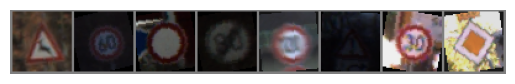

Wild Animals | Speed 60 | No Vehicles | End Speed 80 | Speed 120 | Caution | Speed 30 | Priority Road


In [ ]:
def imshow(img):
    img = img / 2 + 0.5      # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print(' | '.join(classes[labels[j]] for j in range(8)))

### 4. Define the CNN

We use a **deeper network** with 3 convolutional blocks instead of 2.  
Each block has: `Conv2d → BatchNorm → ReLU → MaxPool`

**Why BatchNorm?** It stabilizes training and allows the network to learn faster and more accurately.

**Why more filters?** 43 classes need more feature maps than 10 classes to tell signs apart.

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool  = nn.MaxPool2d(2, 2)

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # After 3 max-pools on 48x48 input: 48 -> 24 -> 12 -> 6
        self.fc1     = nn.Linear(128 * 6 * 6, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(256, 43)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 48 -> 24
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 24 -> 12
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 12 ->  6
        x = x.view(-1, 128 * 6 * 6)                      # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


net = Net()
print(net)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=43, bias=True)
)


### 5. Define Loss Function and Optimizer

We use **Adam** optimizer instead of SGD — it converges faster and gives better accuracy.  
We also use a **learning rate scheduler** that halves the LR every 5 epochs.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Reduce learning rate by half every 5 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

### 6. Train the Network

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')
net.to(device)

for epoch in range(20):          # 20 epochs is enough for 95%+
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'[Epoch {epoch + 1:2d}, Batch {i + 1:4d}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

    scheduler.step()             # adjust learning rate after each epoch
    print(f'--- Epoch {epoch + 1} done | LR: {scheduler.get_last_lr()[0]:.6f} ---')

print('Finished Training')

Training on: cuda:0
[Epoch  1, Batch  100] loss: 3.308
[Epoch  1, Batch  200] loss: 2.326
[Epoch  1, Batch  300] loss: 1.838
[Epoch  1, Batch  400] loss: 1.489
--- Epoch 1 done | LR: 0.001000 ---
[Epoch  2, Batch  100] loss: 1.159
[Epoch  2, Batch  200] loss: 0.967
[Epoch  2, Batch  300] loss: 0.867
[Epoch  2, Batch  400] loss: 0.730
--- Epoch 2 done | LR: 0.001000 ---
[Epoch  3, Batch  100] loss: 0.640
[Epoch  3, Batch  200] loss: 0.619
[Epoch  3, Batch  300] loss: 0.551
[Epoch  3, Batch  400] loss: 0.517
--- Epoch 3 done | LR: 0.001000 ---
[Epoch  4, Batch  100] loss: 0.458
[Epoch  4, Batch  200] loss: 0.445
[Epoch  4, Batch  300] loss: 0.437
[Epoch  4, Batch  400] loss: 0.413
--- Epoch 4 done | LR: 0.001000 ---
[Epoch  5, Batch  100] loss: 0.402
[Epoch  5, Batch  200] loss: 0.377
[Epoch  5, Batch  300] loss: 0.376
[Epoch  5, Batch  400] loss: 0.348
--- Epoch 5 done | LR: 0.000500 ---
[Epoch  6, Batch  100] loss: 0.291
[Epoch  6, Batch  200] loss: 0.286
[Epoch  6, Batch  300] loss: 0

### 7. Save the Model

In [ ]:
PATH = './gtsrb_net.pth'
torch.save(net.state_dict(), PATH)
print('Model saved.')

Model saved.


### 8. Test the Network — Overall Accuracy

In [ ]:
net = Net()
net.load_state_dict(torch.load(PATH))
net.to(device)

correct = 0
total   = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on test set: {100 * correct / total:.2f} %')

Accuracy on test set: 90.68 %
